In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

print("All libraries imported successfully!")

All libraries imported successfully!


In [25]:
# Initial conditions:
# [theta1, omega1, theta2, omega2]

y0 = [
    np.pi / 2,   # theta1(0)
    0.0,         # omega1(0)
    np.pi / 2,   # theta2(0)
    0.0          # omega2(0)
]

# Time span
t_start = 0
t_end = 20

# Time points where the solution will be evaluated
t_eval = np.linspace(t_start, t_end, 2000)

print("Initial conditions set.")

Initial conditions set.


In [26]:
def double_pendulum(t, y):
    theta1, omega1, theta2, omega2 = y

    delta = theta2 - theta1

    den1 = (m1 + m2) * L1 - m2 * L1 * np.cos(delta)**2
    den2 = (L2 / L1) * den1

    dtheta1_dt = omega1
    dtheta2_dt = omega2

    domega1_dt = (
        m2 * L1 * omega1**2 * np.sin(delta) * np.cos(delta)
        + m2 * g * np.sin(theta2) * np.cos(delta)
        + m2 * L2 * omega2**2 * np.sin(delta)
        - (m1 + m2) * g * np.sin(theta1)
    ) / den1

    domega2_dt = (
        -m2 * L2 * omega2**2 * np.sin(delta) * np.cos(delta)
        + (m1 + m2) * (
            g * np.sin(theta1) * np.cos(delta)
            - L1 * omega1**2 * np.sin(delta)
            - g * np.sin(theta2)
        )
    ) / den2

    return [dtheta1_dt, domega1_dt, dtheta2_dt, domega2_dt]

In [27]:
g = 9.81   # gravitational acceleration (m/s^2)
L1 = 1.0   # length of first rod (m)
L2 = 1.0   # length of second rod (m)
m1 = 1.0   # mass of first bob (kg)
m2 = 1.0   # mass of second bob (kg)

print("Parameters initialized.")

Parameters initialized.


In [28]:
solution = solve_ivp(
    double_pendulum,
    (t_start, t_end),
    y0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

print("Simulation complete.")

Simulation complete.


In [29]:
theta1 = solution.y[0]
omega1 = solution.y[1]
theta2 = solution.y[2]
omega2 = solution.y[3]

print("Results extracted.")

Results extracted.


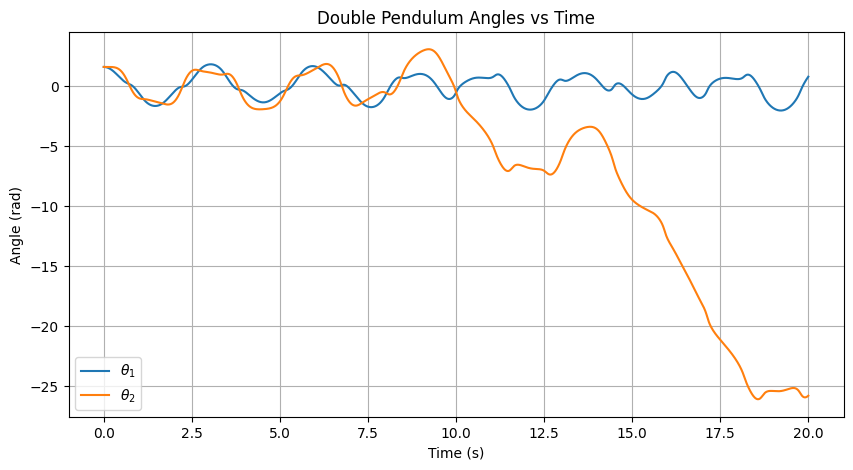

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(solution.t, theta1, label=r'$\theta_1$')
plt.plot(solution.t, theta2, label=r'$\theta_2$')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Double Pendulum Angles vs Time')
plt.legend()
plt.grid(True)
plt.show()